# Projeto Airbnb Rio - Ferramenta de Previsão de Preço de Imóvel para pessoas comuns 

Etapas seguidas

1. Entendimento do desafio que você quer resolver
2. Entendimento da empresa/área
3. Extração/obtenção de dados
4. Ajuste de Dados (limpeza de dados)
5. Análise Explorrattórria
6. Modelagem + Algoritmos
7. Interpretação dos resultados
8. Deploy/Produção

### Contexto

No Airbnb, qualquer pessoa que tenha um quarto ou um imóvel de qualquer tipo (apartamento, casa, chalé, pousada, etc.) pode ofertar o seu imóvel para ser alugado por diária.

Você cria o seu perfil de host (pessoa que disponibiliza um imóvel para aluguel por diária) e cria o anúncio do seu imóvel.

Nesse anúncio, o host deve descrever as características do imóvel da forma mais completa possível, de forma a ajudar os locadores/viajantes a escolherem o melhor imóvel para eles (e de forma a tornar o seu anúncio mais atrativo)

Existem dezenas de personalizações possíveis no seu anúncio, desde quantidade mínima de diária, preço, quantidade de quartos, até regras de cancelamento, taxa extra para hóspedes extras, exigência de verificação de identidade do locador, etc.

### Objetivo

Construir um modelo de previsão de preço que permita uma pessoa comum que possui um imóvel possa saber quanto deve cobrar pela diária do seu imóvel.

Ou ainda, para o locador comum, dado o imóvel que ele está buscando, ajudar a saber se aquele imóvel está com preço atrativo (abaixo da média para imóveis com as mesmas características) ou não.

### O que se tem disponível, inspirações e créditos

As bases de dados foram retiradas do site kaggle: https://www.kaggle.com/allanbruno/airbnb-rio-de-janeiro

Pode-se olhar como referência a solução do usuário Allan Bruno do kaggle no Notebook: https://www.kaggle.com/allanbruno/helping-regular-people-price-listings-on-airbnb

Pode-se perceber semelhanças entre a solução aqui desenvolvida e a dele, mas também algumas diferenças significativas no processo de construção do projeto.

- As bases de dados são os preços dos imóveis obtidos e suas respectivas características em cada mês.
- Os preços são dados em reais (R$)
- As bases são de abril de 2018 a maio de 2020, com exceção de junho de 2018 que não possui base de dados

### Expectativas Iniciais

- Acredito que a sazonalidade pode ser um fator importante, visto que meses como dezembro costumam ser bem caros no RJ
- A localização do imóvel deve fazer muita diferença no preço, já que no Rio de Janeiro a localização pode mudar completamente as características do lugar (segurança, beleza natural, pontos turísticos)
- Adicionais/Comodidades podem ter um impacto significativo, visto que temos muitos prédios e casas antigos no Rio de Janeiro

O objetivo é descobrir o quanto esses fatores impactam e se tem outros fatores não tão intuitivos que são extremamente importantes.

### Importar Bibliotecas e Bases de Dados

In [124]:
import pandas as pd
import pathlib
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from sklearn.model_selection import train_test_split


### Consolidar Base de Dados

In [125]:
# Colocando todas as bases de dados dentro de uma base de dados única
meses = {
    'jan': 1,
    'fev': 2,
    'mar': 3,
    'abr': 4,
    'mai': 5,
    'jun': 6,
    'jul': 7,
    'ago': 8,
    'set': 9,
    'out': 10,
    'nov': 11,
    'dez': 12
}

caminho_bases = pathlib.Path('dataset')# Passa a pasta em que as bases estão

base_airbnb = pd.DataFrame()

for arquivo in caminho_bases.iterdir(): # Iterando os arquivos dentro do diretório informado
    nome_mes = arquivo.name[:3]
    mes = meses[nome_mes]

    ano = arquivo.name[-8:]
    ano = int(ano.replace(".csv", ""))

    df = pd.read_csv(caminho_bases / arquivo.name)
    df["ano"] = ano
    df["mes"] = mes
    base_airbnb = pd.concat([base_airbnb, df], ignore_index=True)

display(base_airbnb)


C:\Users\david\AppData\Local\Temp\ipykernel_11840\3097333358.py:28: DtypeWarning: Columns (0: monthly_price, 1: license) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(caminho_bases / arquivo.name)
C:\Users\david\AppData\Local\Temp\ipykernel_11840\3097333358.py:28: DtypeWarning: Columns (0: weekly_price, 1: monthly_price, 2: license) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(caminho_bases / arquivo.name)
C:\Users\david\AppData\Local\Temp\ipykernel_11840\3097333358.py:28: DtypeWarning: Columns (0: license) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(caminho_bases / arquivo.name)


,id,listing_url,scrape_id,last_scraped,name,summary,space,description,experiences_offered,neighborhood_overview,...,minimum_minimum_nights,maximum_minimum_nights,minimum_maximum_nights,maximum_maximum_nights,minimum_nights_avg_ntm,maximum_nights_avg_ntm,number_of_reviews_ltm,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms
0,14063,https://www.airbnb.com/rooms/14063,20180414160018,2018-04-14,Living in a Postcard,"Besides the most iconic's view, our apartment ...",NaN,"Besides the most iconic's view, our apartment ...",none,Best and favorite neighborhood of Rio. Perfect...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,17878,https://www.airbnb.com/rooms/17878,20180414160018,2018-04-14,Very Nice 2Br - Copacabana - WiFi,Please note that special rates apply for New Y...,- large balcony which looks out on pedestrian ...,Please note that special rates apply for New Y...,none,This is the best spot in Rio. Everything happe...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,24480,https://www.airbnb.com/rooms/24480,20180414160018,2018-04-14,Nice and cozy near Ipanema Beach,My studio is located in the best of Ipanema. ...,The studio is located at Vinicius de Moraes St...,My studio is located in the best of Ipanema. ...,none,"The beach, the lagoon, Ipanema is a great loca...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,25026,https://www.airbnb.com/rooms/25026,20180414160018,2018-04-14,Beautiful Modern Decorated Studio in Copa,"Our apartment is a little gem, everyone loves ...",This newly renovated studio (last renovations ...,"Our apartment is a little gem, everyone loves ...",none,Copacabana is a lively neighborhood and the ap...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,31560,https://www.airbnb.com/rooms/31560,20180414160018,2018-04-14,NICE & COZY 1BDR - IPANEMA BEACH,This nice and clean 1 bedroom apartment is loc...,This nice and clean 1 bedroom apartment is loc...,This nice and clean 1 bedroom apartment is loc...,none,Die Nachbarschaft von Ipanema ist super lebend...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
902205,38844730,https://www.airbnb.com/rooms/38844730,20190923212307,2019-09-24,TRANSAMERICA BARRA DA TIJUCA R IV,"Em estilo contemporâneo, o Transamerica Prime ...",NaN,"Em estilo contemporâneo, o Transamerica Prime ...",none,NaN,...,1.0,1.0,1125.0,1125.0,1.0,1125.0,0.0,15.0,0.0,0.0
902206,38846408,https://www.airbnb.com/rooms/38846408,20190923212307,2019-09-24,Alugo para o Rock in Rio,"Confortável apartamento, 2 quartos , sendo 1 s...",O apartamento estará com mobília completa disp...,"Confortável apartamento, 2 quartos , sendo 1 s...",none,"Muito próximo ao Parque Olímpico, local do eve...",...,2.0,2.0,1125.0,1125.0,2.0,1125.0,0.0,1.0,0.0,0.0
902207,38846703,https://www.airbnb.com/rooms/38846703,20190923212307,2019-09-24,Apt COMPLETO em COPACABANA c/TOTAL SEGURANÇA,Apartamento quarto e sala COMPLETO para curtas...,Espaço ideal para até 5 pessoas. Cama de casal...,Apartamento quarto e sala COMPLETO para curtas...,none,NaN,...,3.0,3.0,1125.0,1125.0,3.0,1125.0,0.0,23.0,6.0,0.0
902208,38847050,https://www.airbnb.com/rooms/38847050,20190923212307,2019-09-24,Cobertura Cinematografica,Cobertura alto nivel,NaN,Cobertura alto nivel,none,NaN,...,1.0,1.0,1125.0,1125.0,1.0,1125.0,0.0,1.0,0.0,0.0


### Identificação e exclusão de colunas inúteis para o objetivo

In [ ]:
""" 
- Uma análise rápida permite ver que várias colunas não são necessárias para o modelo de previsão, por isso 
algumas colunas serão excluidas

Tipos de colunas excluidas:
1. IDs, Links e informações não relevantes para o modelo
2. Colunas repetidas ou extremamente parecidas com outras (que dão a mesma informação. EX.: Data x Ano/Mês)
3. Colunas preenchidas com texto livre -> Não será feito nenhuma análise de palavras ou algo do tipo
4. Colunas em que todos ou quase todos os valores são iguais (Ex.: colunas vazias)

- Para isso, será criado um arquivo em excel com os 1000 primeiros registros e fazer um análise qualitativa
"""

print(list(base_airbnb.columns))
# Eu abri a base em um csv 
base_airbnb.head(1000).to_csv('primeros registros.csv', sep=";", index=False)
# e exclui as colunas inúteis

['id', 'listing_url', 'scrape_id', 'last_scraped', 'name', 'summary', 'space', 'description', 'experiences_offered', 'neighborhood_overview', 'notes', 'transit', 'access', 'interaction', 'house_rules', 'thumbnail_url', 'medium_url', 'picture_url', 'xl_picture_url', 'host_id', 'host_url', 'host_name', 'host_since', 'host_location', 'host_about', 'host_response_time', 'host_response_rate', 'host_acceptance_rate', 'host_is_superhost', 'host_thumbnail_url', 'host_picture_url', 'host_neighbourhood', 'host_listings_count', 'host_total_listings_count', 'host_verifications', 'host_has_profile_pic', 'host_identity_verified', 'street', 'neighbourhood', 'neighbourhood_cleansed', 'neighbourhood_group_cleansed', 'city', 'state', 'zipcode', 'market', 'smart_location', 'country_code', 'country', 'latitude', 'longitude', 'is_location_exact', 'property_type', 'room_type', 'accommodates', 'bathrooms', 'bedrooms', 'beds', 'bed_type', 'amenities', 'square_feet', 'price', 'weekly_price', 'monthly_price', '

In [127]:
print(base_airbnb[["experiences_offered"]].value_counts(),"\n")# Coluna vazia

print(base_airbnb["host_acceptance_rate"].value_counts(),"\n")

print((base_airbnb["host_listings_count"]==base_airbnb["host_total_listings_count"]).value_counts(),"\n")# A maior parte são valores iguais, então host_total_listings_count será removido

print(base_airbnb["square_feet"].isnull().sum()) # Muitos valores vazios, será excluida

experiences_offered
none                   902210
Name: count, dtype: int64 

host_acceptance_rate
100%    31697
0%       4744
50%      3781
99%      3320
67%      3140
        ...  
28%        22
15%        21
7%         20
51%        18
6%         11
Name: count, Length: 100, dtype: int64 

True     901750
False       460
Name: count, dtype: int64 

888162


### Depois da análise qualitativa das colunas, levando em conta os critérios explicados acima, ficamos com as seguintes colunas:

In [128]:
# Puxei as colunas restantes do csv
colunas = ['host_response_time','host_response_rate','host_is_superhost','host_listings_count','latitude','longitude','property_type','room_type','accommodates','bathrooms','bedrooms','beds','bed_type','amenities','price','security_deposit','cleaning_fee','guests_included','extra_people','minimum_nights','maximum_nights','number_of_reviews','review_scores_rating','review_scores_accuracy','review_scores_cleanliness','review_scores_checkin','review_scores_communication','review_scores_location','review_scores_value','instant_bookable','is_business_travel_ready','cancellation_policy','ano','mes']
base_airbnb = base_airbnb.loc[:, colunas]

display(base_airbnb)

,host_response_time,host_response_rate,host_is_superhost,host_listings_count,latitude,longitude,property_type,room_type,accommodates,bathrooms,...,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,instant_bookable,is_business_travel_ready,cancellation_policy,ano,mes
0,NaN,NaN,f,1.0,-22.946854,-43.182737,Apartment,Entire home/apt,4,1.0,...,9.0,9.0,9.0,9.0,9.0,f,f,strict_14_with_grace_period,2018,4
1,within an hour,100%,t,2.0,-22.965919,-43.178962,Condominium,Entire home/apt,5,1.0,...,9.0,10.0,10.0,9.0,9.0,t,f,strict,2018,4
2,within an hour,100%,f,1.0,-22.985698,-43.201935,Apartment,Entire home/apt,2,1.0,...,10.0,10.0,10.0,10.0,9.0,f,f,strict,2018,4
3,within an hour,100%,f,3.0,-22.977117,-43.190454,Apartment,Entire home/apt,3,1.0,...,10.0,10.0,10.0,10.0,9.0,f,f,strict,2018,4
4,within an hour,100%,t,1.0,-22.983024,-43.214270,Apartment,Entire home/apt,3,1.0,...,10.0,10.0,10.0,10.0,9.0,t,f,strict,2018,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
902205,within an hour,93%,f,0.0,-23.003180,-43.342840,Apartment,Entire home/apt,4,1.0,...,NaN,NaN,NaN,NaN,NaN,f,f,flexible,2019,9
902206,NaN,NaN,f,0.0,-22.966640,-43.393450,Apartment,Entire home/apt,4,2.0,...,NaN,NaN,NaN,NaN,NaN,f,f,flexible,2019,9
902207,within a few hours,74%,f,32.0,-22.962080,-43.175520,Apartment,Entire home/apt,5,1.0,...,NaN,NaN,NaN,NaN,NaN,f,f,strict_14_with_grace_period,2019,9
902208,NaN,NaN,f,0.0,-23.003400,-43.341820,Apartment,Entire home/apt,4,1.0,...,NaN,NaN,NaN,NaN,NaN,f,f,strict_14_with_grace_period,2019,9


### Tratar Valores Faltando

##### - Depois de uma análise de dados das colunas, constatei que haviam colunas com muitas linhas com valores nulos, então essas colunas foram retiradas. As colunas com mais de 300.000 valores nulos foram removidas

##### - Para as outras colunas, serão excluidas as linhas com dados nulos

In [129]:
for coluna in base_airbnb:
    if base_airbnb[coluna].isnull().sum() > 300000:# Tira todas as colunas com mais de 300.000 linhas com valores nulos
        base_airbnb = base_airbnb.drop(columns=coluna)
print("Base de dados depois das colunas null serem excluidas\n",base_airbnb.isnull().sum(),"\n")

print(base_airbnb.shape)

Base de dados depois das colunas null serem excluidas
 host_is_superhost            460
host_listings_count          460
latitude                       0
longitude                      0
property_type                  0
room_type                      0
accommodates                   0
bathrooms                   1724
bedrooms                     850
beds                        2502
bed_type                       0
amenities                      0
price                          0
guests_included                0
extra_people                   0
minimum_nights                 0
maximum_nights                 0
number_of_reviews              0
instant_bookable               0
is_business_travel_ready       0
cancellation_policy            0
ano                            0
mes                            0
dtype: int64 

(902210, 23)


In [130]:
# Tirando as linhas vazias
base_airbnb = base_airbnb.dropna()
print(base_airbnb.shape,"\n")
print(base_airbnb.isnull().sum())

(897709, 23) 

host_is_superhost           0
host_listings_count         0
latitude                    0
longitude                   0
property_type               0
room_type                   0
accommodates                0
bathrooms                   0
bedrooms                    0
beds                        0
bed_type                    0
amenities                   0
price                       0
guests_included             0
extra_people                0
minimum_nights              0
maximum_nights              0
number_of_reviews           0
instant_bookable            0
is_business_travel_ready    0
cancellation_policy         0
ano                         0
mes                         0
dtype: int64


### Verificar Tipos de Dados em cada coluna

In [131]:
print(base_airbnb.dtypes)
display(base_airbnb.head(1))

host_is_superhost               str
host_listings_count         float64
latitude                    float64
longitude                   float64
property_type                   str
room_type                       str
accommodates                  int64
bathrooms                   float64
bedrooms                    float64
beds                        float64
bed_type                        str
amenities                       str
price                           str
guests_included               int64
extra_people                    str
minimum_nights                int64
maximum_nights                int64
number_of_reviews             int64
instant_bookable                str
is_business_travel_ready        str
cancellation_policy             str
ano                           int64
mes                           int64
dtype: object


,host_is_superhost,host_listings_count,latitude,longitude,property_type,room_type,accommodates,bathrooms,bedrooms,beds,...,guests_included,extra_people,minimum_nights,maximum_nights,number_of_reviews,instant_bookable,is_business_travel_ready,cancellation_policy,ano,mes
0,f,1.0,-22.946854,-43.182737,Apartment,Entire home/apt,4,1.0,0.0,2.0,...,2,$34.00,60,365,38,f,f,strict_14_with_grace_period,2018,4


- Como as colunas 'price' e 'extra people' estão sendo reconhecidas com str e deveriam ser float, é necessário mudas o tipo delas

In [132]:
"""
Colunas com tipos errados:

prince (tipo str) -> tem que ser float
extra_people (tipo str) -> tem que ser float
"""
# Modificando a coluna price
base_airbnb["price"] = base_airbnb["price"].str.replace("$","")
base_airbnb["price"] = base_airbnb["price"].str.replace(",","")
base_airbnb["price"] = base_airbnb["price"].astype(np.float32, copy = False)

# Modificando a coluna extra_people
base_airbnb["extra_people"] = base_airbnb["extra_people"].str.replace("$","")
base_airbnb["extra_people"] = base_airbnb["extra_people"].str.replace(",","")
base_airbnb["extra_people"] = base_airbnb["extra_people"].astype(np.float32, copy = False)

# verificando os tipos

print(base_airbnb.dtypes)

C:\Users\david\AppData\Local\Temp\ipykernel_11840\1067088644.py:10: Pandas4Warning: The copy keyword is deprecated and will be removed in a future version. Copy-on-Write is active in pandas since 3.0 which utilizes a lazy copy mechanism that defers copies until necessary. Use .copy() to make an eager copy if necessary.
  base_airbnb["price"] = base_airbnb["price"].astype(np.float32, copy = False)
C:\Users\david\AppData\Local\Temp\ipykernel_11840\1067088644.py:15: Pandas4Warning: The copy keyword is deprecated and will be removed in a future version. Copy-on-Write is active in pandas since 3.0 which utilizes a lazy copy mechanism that defers copies until necessary. Use .copy() to make an eager copy if necessary.
  base_airbnb["extra_people"] = base_airbnb["extra_people"].astype(np.float32, copy = False)


host_is_superhost               str
host_listings_count         float64
latitude                    float64
longitude                   float64
property_type                   str
room_type                       str
accommodates                  int64
bathrooms                   float64
bedrooms                    float64
beds                        float64
bed_type                        str
amenities                       str
price                       float32
guests_included               int64
extra_people                float32
minimum_nights                int64
maximum_nights                int64
number_of_reviews             int64
instant_bookable                str
is_business_travel_ready        str
cancellation_policy             str
ano                           int64
mes                           int64
dtype: object


### Análise Exploratória e Tratar Outliers

- Basicamente será observado feature por feature para:
    1. Ver a correlação entre as features e decidir se será mantido todas as features que dispostas.
    2. Excluir outliers (será usado como regra, valores abaixo de Q1 - 1.5xAmplitude e valores acima de Q3 + 1.5x Amplitude). Amplitude = Q3 - Q1
    3. Confirmar se todas as features dispostas fazem realmente sentido para o modelo ou se alguma delas não vai ajudar e se devem ser excluidas
    
- As primeiras a serem analisadas serão as colunas de preço (resultado final que se deseja) e de extra_people (também valor monetário). Esses são os valores numéricos contínuos.

- Depois será analisado as colunas de valores numéricos discretos (accomodates, bedrooms, guests_included, etc.)

- Por fim, será avaliado as colunas de texto e definir quais categorias fazem sentido serem mantidas ou não.


<Axes: >

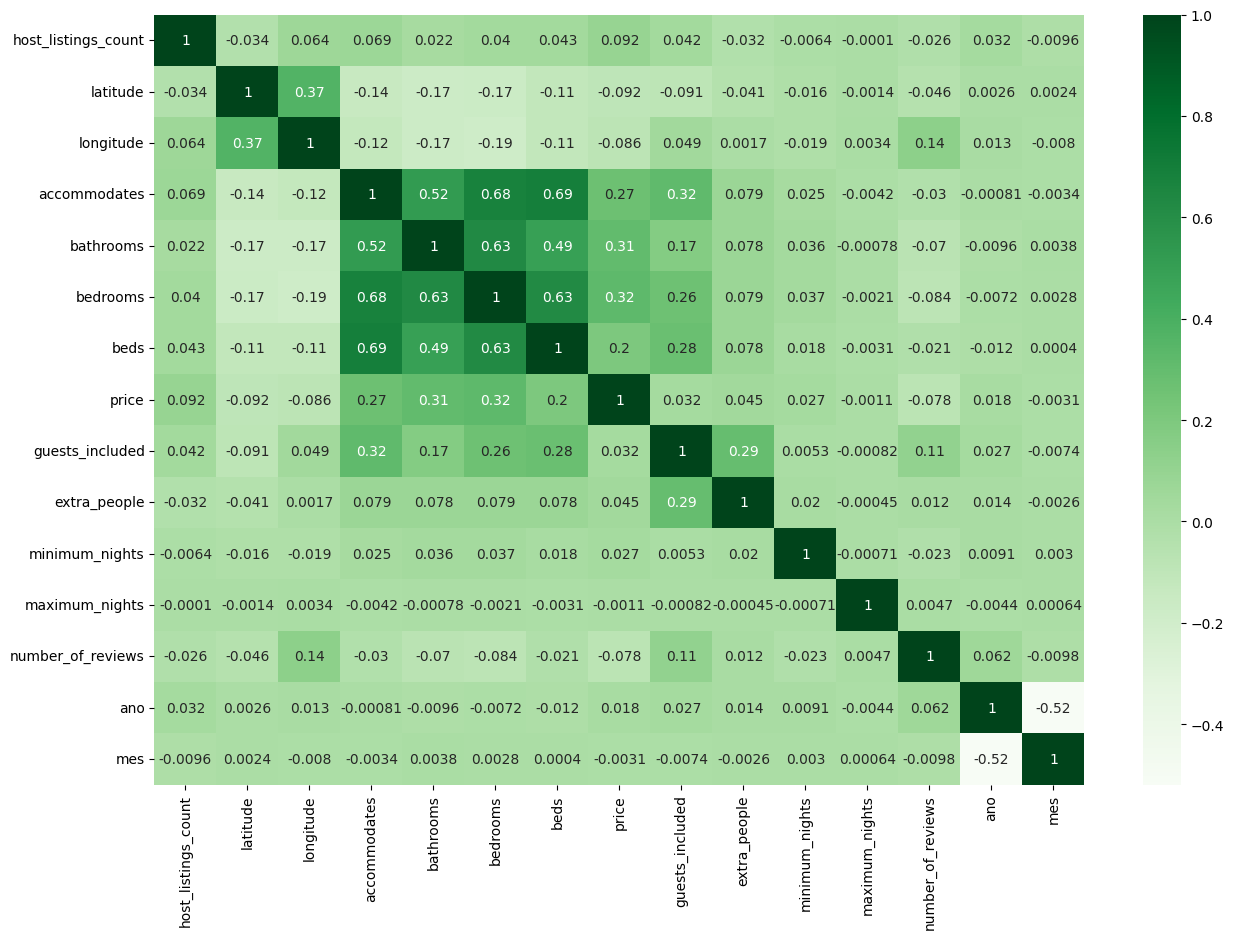

In [133]:
# Análise de corelação
plt.figure(figsize=(15,10))
sns.heatmap(base_airbnb.select_dtypes(include="number").corr(), annot=True, cmap="Greens") # annot -> Descrição do gráfico
# Se tivesse colunas com uma corelaçao muito forte elas poderiam prejudicar o modelo, por basicamente dizerem a mesma coisa

### Definição de Funções para Análise de Outiliers
- Será definido algumas funções úteis na análise de outliers das colunas

In [134]:
"""
Q1 -> primeiro quartil
Q3 -> terceiro quatil

Amplitude = Q3 - Q1
Limite inferior do Outliers Q1 - 1,5 * Amplitude
Limite superior do Outliers Q3 + 1,5 * Amplitude
"""

# Função para calcular os Outliers
def limites (coluna):
    q1 = coluna.quantile(0.25)
    q3 = coluna.quantile(0.75)
    amplitude = q3 - q1
    return q1 - 1.5 * amplitude, q3 + 1.5 * amplitude


In [135]:
# Função para contruir os gráficos de caixa
def diagrama_caixa (coluna):
    fig, (ax1, ax2) = plt.subplots(1,2)
    fig.set_size_inches(15,5)

    sns.boxplot(x=coluna, ax=ax1)

    ax2.set_xlim(limites(coluna)) # Configurar os limites do segundo gráfico de caixa de acordo com os limites de outliers

    sns.boxplot(x=coluna, ax=ax2)
    plt.show()

# Função para excluir os outliers
def excluir_outliers(df, nome_coluna):
    qtde_linhas = df.shape[0] # Pega só o número de linhas
    limite_inf, limite_sup = limites(df[nome_coluna])
    df = df.loc[(df[nome_coluna] >= limite_inf) & (df[nome_coluna] <= limite_sup), :] 
    # Os valores da coluna maior que o limite inferior e menor que o limite superior serão filtrados 
    linhas_removidas = qtde_linhas - df.shape[0]
    return df, linhas_removidas

# Função para criar histogramas
def histogramas(df, nome_coluna):
    plt.figure(figsize=(15,5))
    sns.histplot(x = nome_coluna,  data=df, kde=True)
    plt.show()

def grafico_barra(coluna):
    plt.figure(figsize=(15,5))
    ax = sns.barplot(x = coluna.value_counts().index, y = coluna.value_counts())
    ax.set_xlim(limites(coluna))
    plt.show()


### price

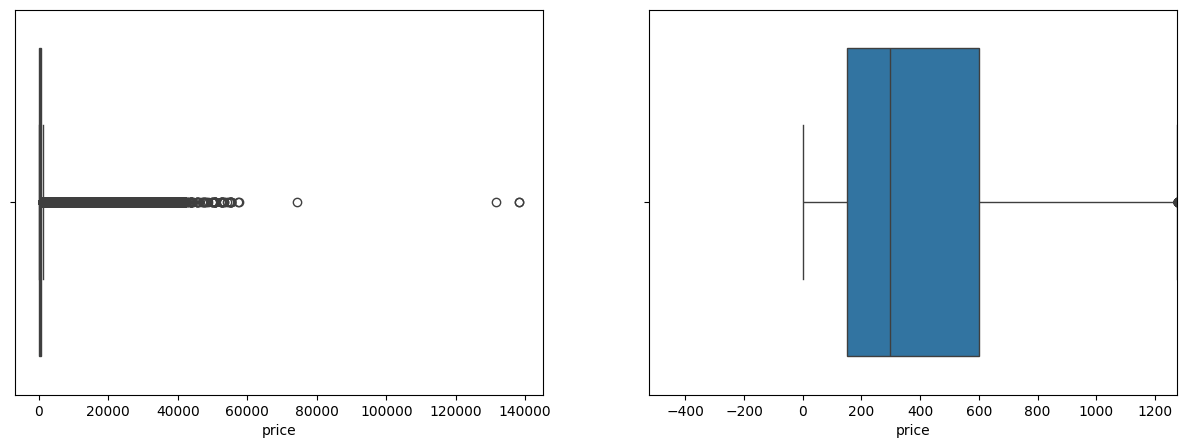

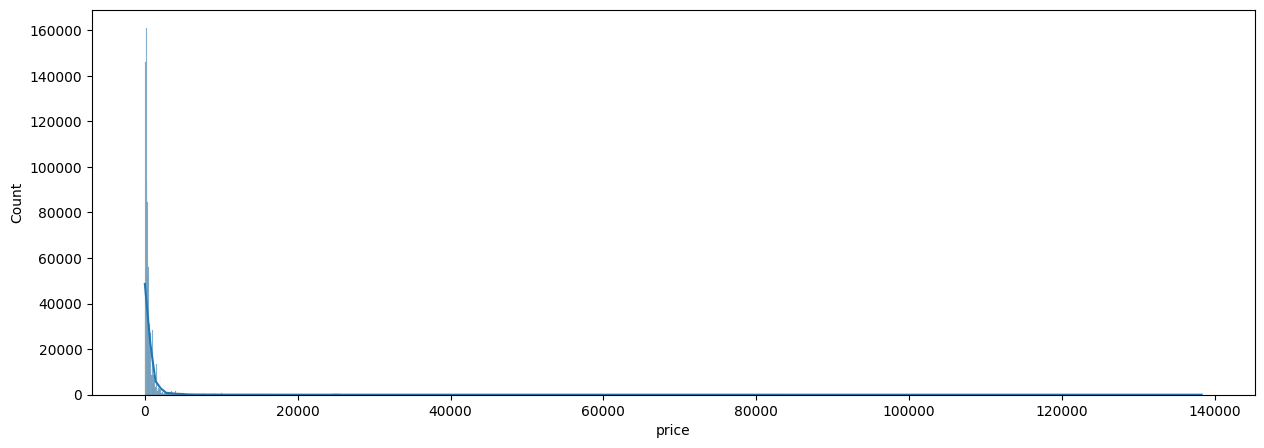

In [136]:
diagrama_caixa(base_airbnb["price"])
histogramas(base_airbnb, "price")


- Como está sendo construido um modelo para imóveis comuns, acredito que os valores acima do limite superior serão apenas de imóveis de altíssimo luxo, que não é o objetivo principal. Por isso, esses outliers serão excluidos

In [137]:
base_airbnb, linhas_removidas = excluir_outliers(base_airbnb, "price")
print(f"Linhas removidas {linhas_removidas}")

Linhas removidas 87282


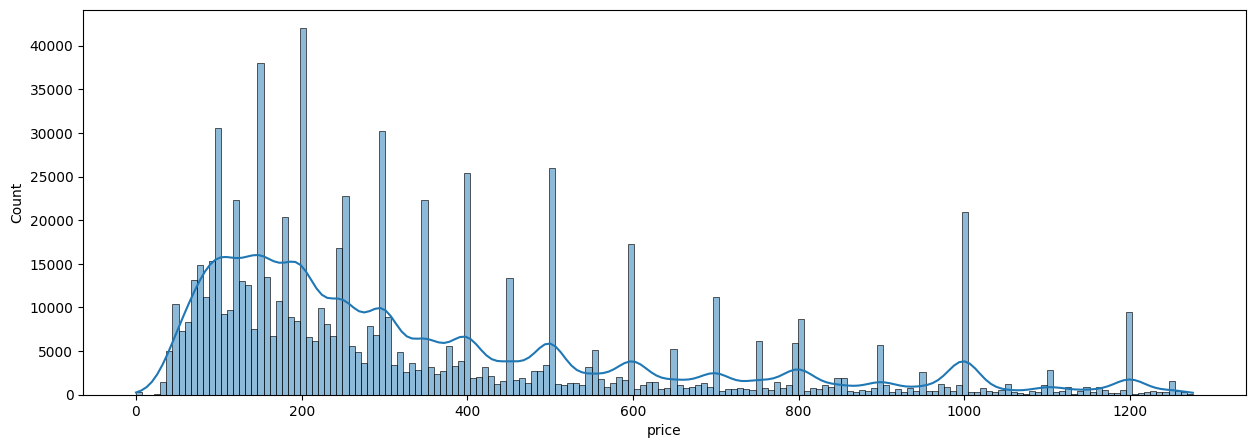

In [138]:
histogramas(base_airbnb, "price")

### extra_people

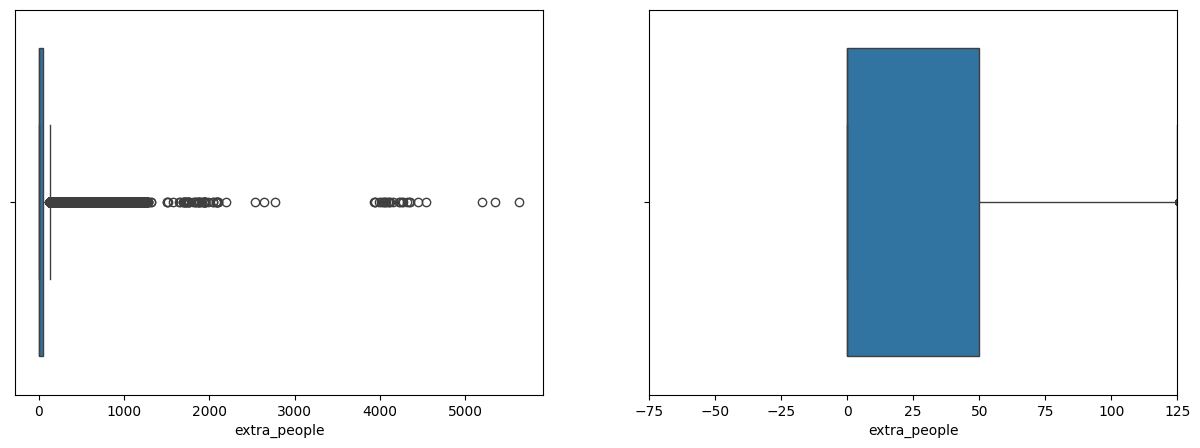

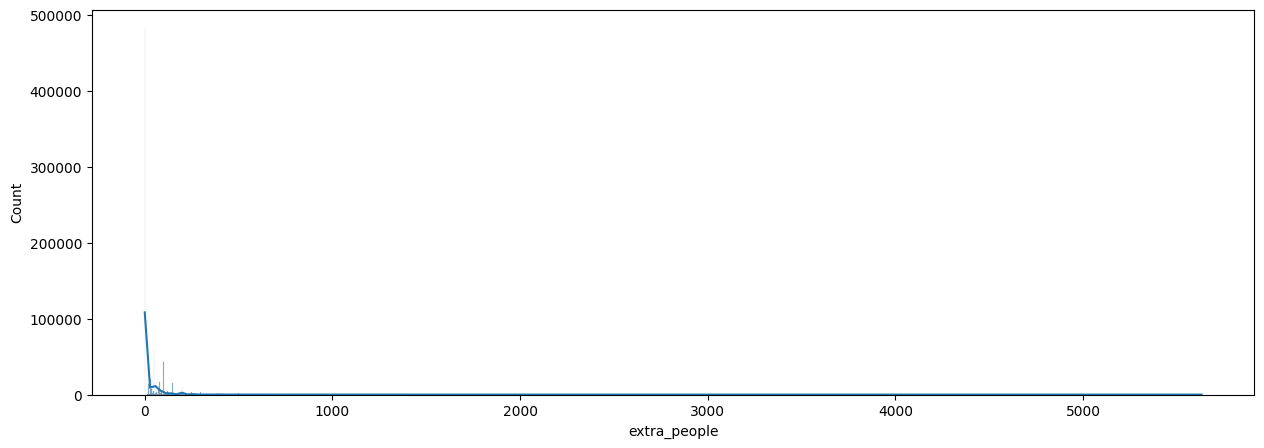

In [139]:
diagrama_caixa(base_airbnb["extra_people"])
histogramas(base_airbnb, "extra_people")


- Como está sendo construido um modelo para imóveis comuns, acredito que os valores acima do limite superior serão apenas de imóveis de altíssimo luxo, que não é o objetivo principal. Por isso, esses outliers serão excluidos

In [140]:
base_airbnb, linhas_removidas = excluir_outliers(base_airbnb, "extra_people")
print(f"Linhas removidas {linhas_removidas}")

Linhas removidas 59194


### host_listings_count 

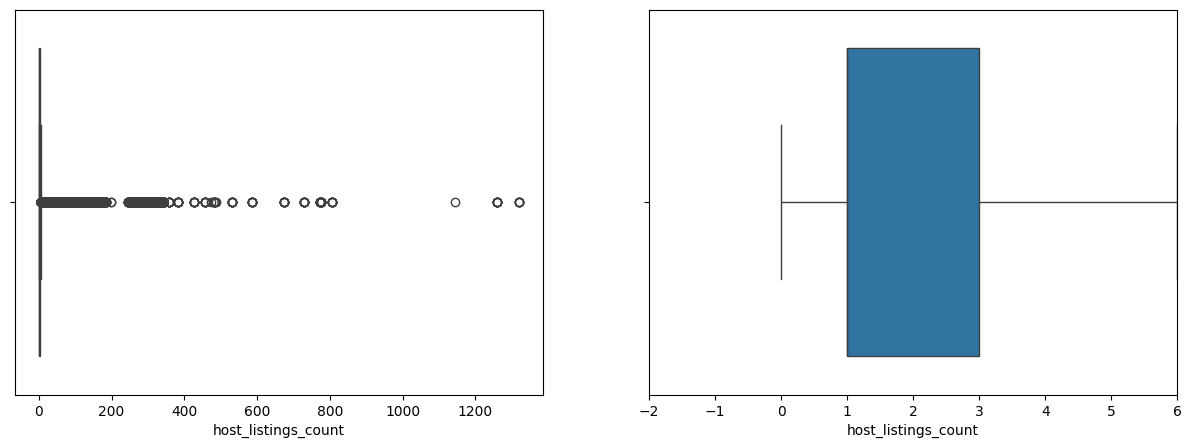

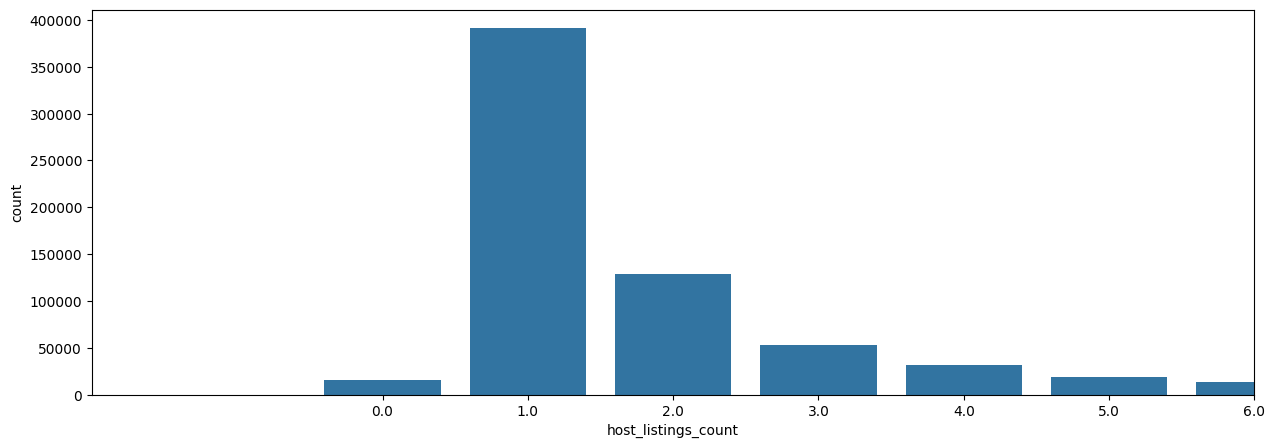

In [141]:
diagrama_caixa(base_airbnb["host_listings_count"])
grafico_barra(base_airbnb["host_listings_count"])

Posso excluir os outliers, porque, para o objetivo do projeto, hosts com mais de 6 imóveis no airbnb não é o público alvo do objetivo do projeto (imagino que sejam imobiliárias ou profissiona) 

In [142]:
base_airbnb, linhas_removidas = excluir_outliers(base_airbnb, "host_listings_count")
print(f"Linhas removidas {linhas_removidas}")

Linhas removidas 97723


### accommodates 

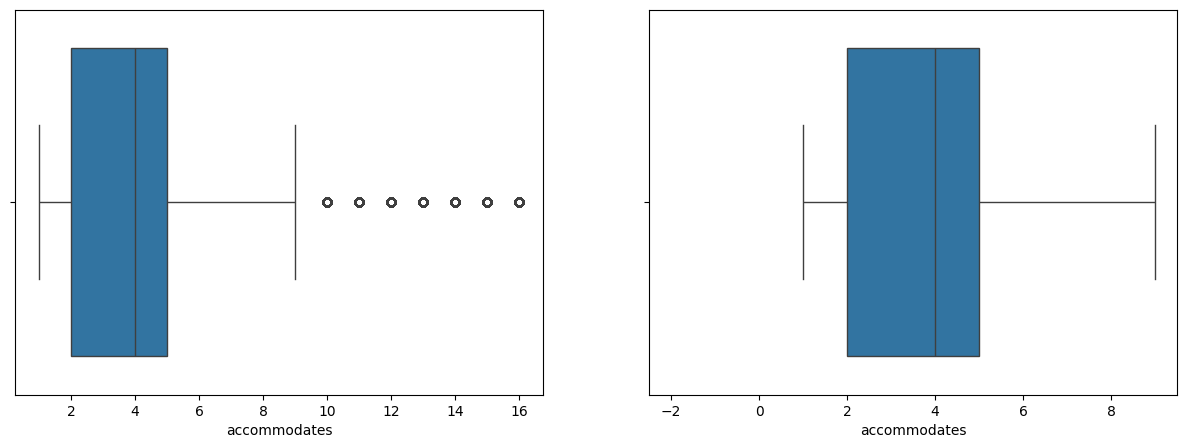

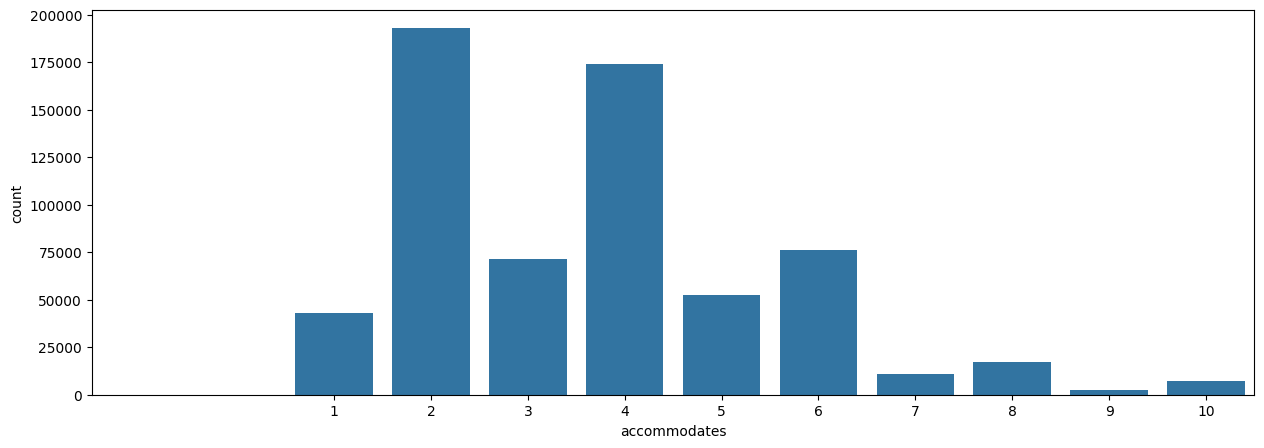

In [143]:
diagrama_caixa(base_airbnb["accommodates"])
grafico_barra(base_airbnb["accommodates"])

In [144]:
base_airbnb, linhas_removidas = excluir_outliers(base_airbnb, "accommodates")
print(f"Linhas removidas {linhas_removidas}")

Linhas removidas 13146


### bathrooms

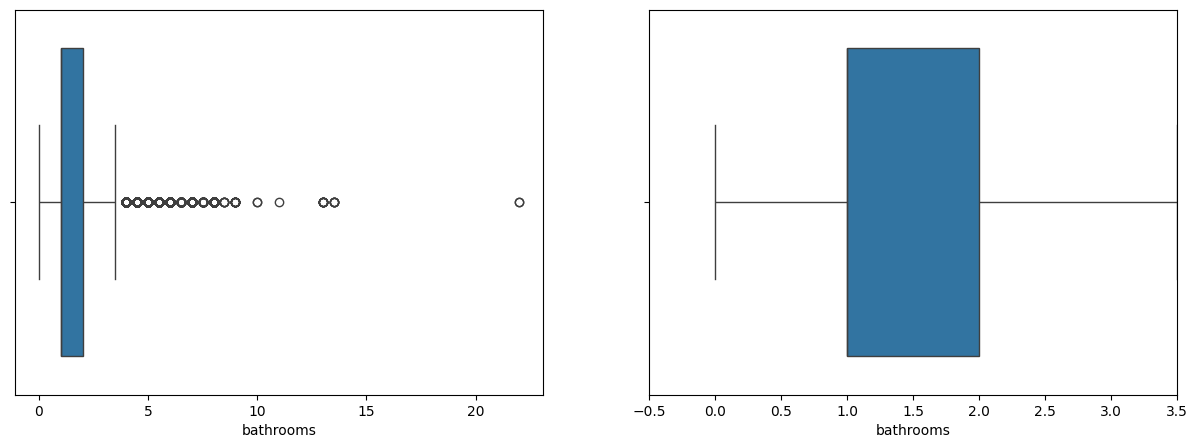

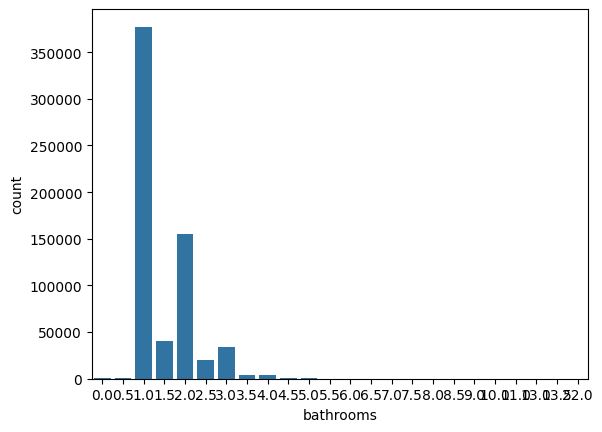

In [145]:
diagrama_caixa(base_airbnb["bathrooms"])
sns.barplot(x = base_airbnb["bathrooms"].value_counts().index, y = base_airbnb["bathrooms"].value_counts())
plt.show()

In [146]:
base_airbnb, linhas_removidas = excluir_outliers(base_airbnb, "bathrooms")
print(f"Linhas removidas {linhas_removidas}")

Linhas removidas 6894


### bedrooms

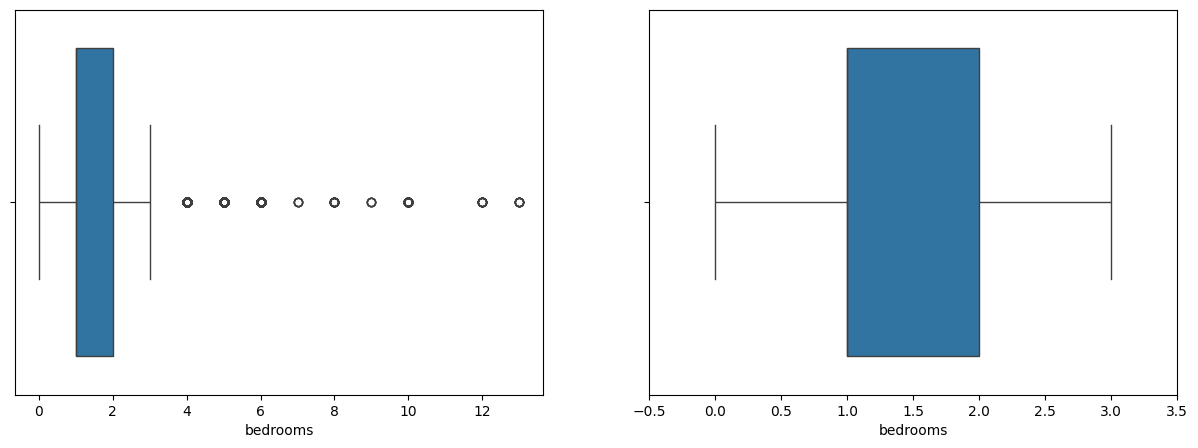

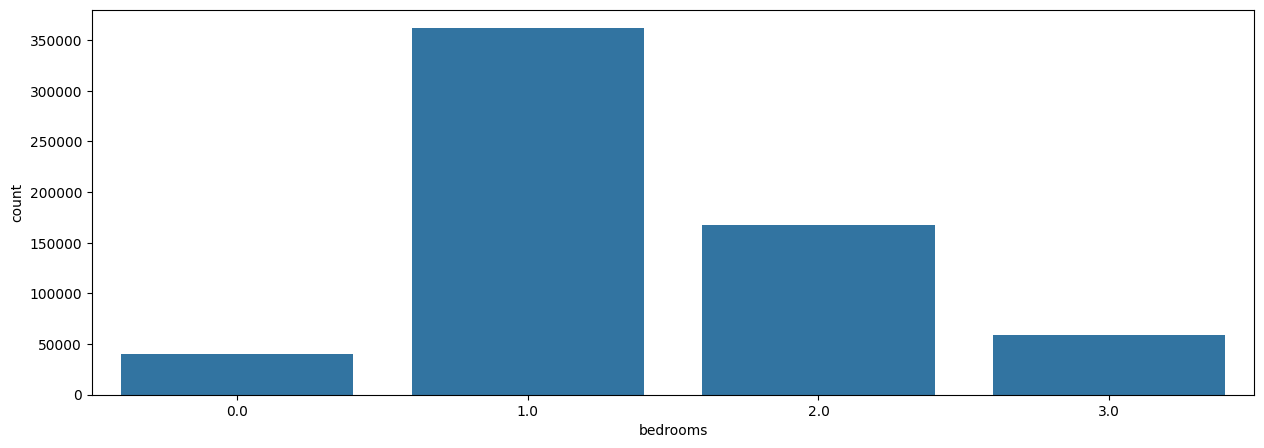

In [147]:
diagrama_caixa(base_airbnb["bedrooms"])
grafico_barra(base_airbnb["bedrooms"])

In [148]:
base_airbnb, linhas_removidas = excluir_outliers(base_airbnb, "bedrooms")
print(f"Linhas removidas {linhas_removidas}")

Linhas removidas 5482


### beds

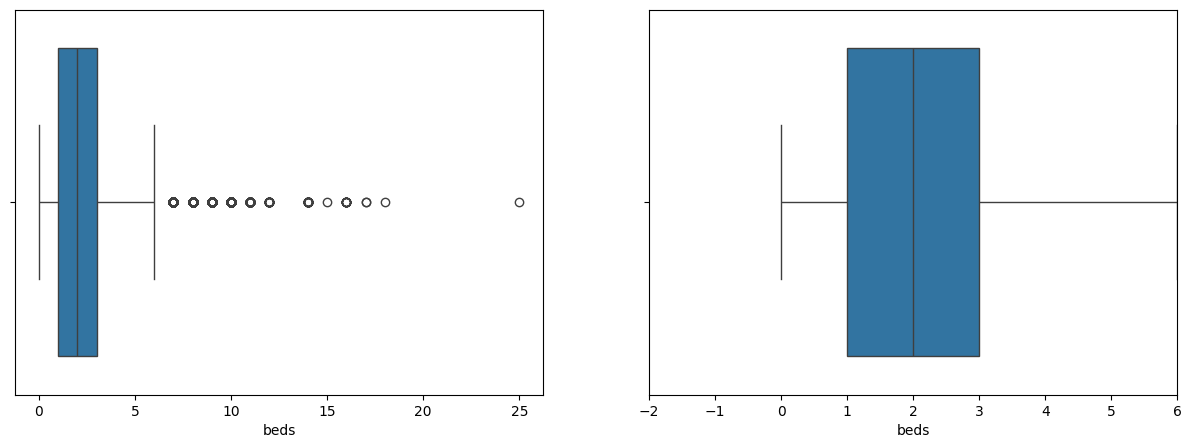

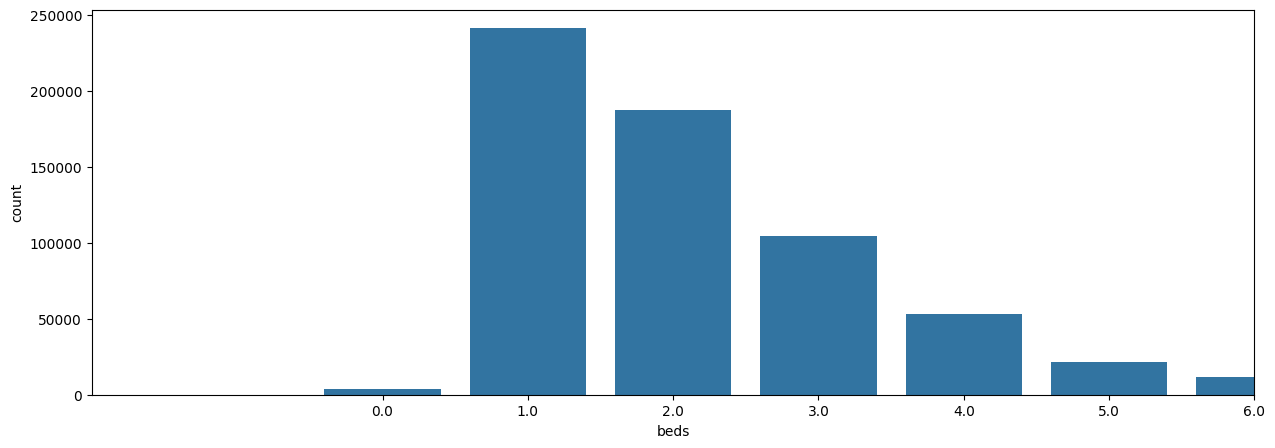

In [149]:
diagrama_caixa(base_airbnb["beds"])
grafico_barra(base_airbnb["beds"])

In [150]:
base_airbnb, linhas_removidas = excluir_outliers(base_airbnb, "beds")
print(f"Linhas removidas {linhas_removidas}")

Linhas removidas 5622


### guests_included

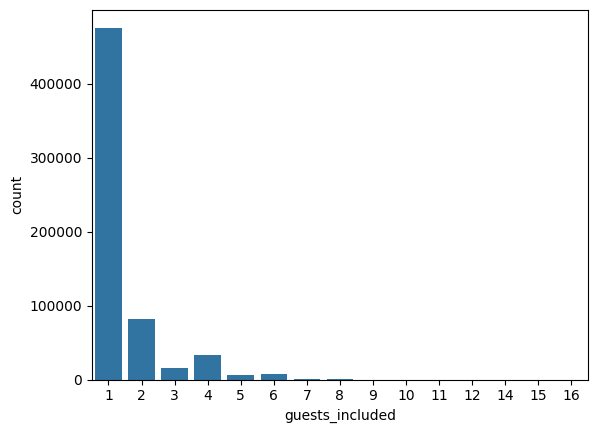

In [151]:
sns.barplot(x = base_airbnb["guests_included"].value_counts().index, y = base_airbnb["guests_included"].value_counts())
plt.show()

- Essa feature será excluida da análise. Parece que os usuários do airbnb usam muito o valor padrão do airbnb como 1 guest included. Isso pode levar o modelo a considerar uma feature que na verdade não é essencial para a definição do preço, por isso parece melhor excluir essa coluna da análise. 

In [152]:
base_airbnb = base_airbnb.drop(columns="guests_included")
base_airbnb.shape

(622366, 22)

### minimum_nights

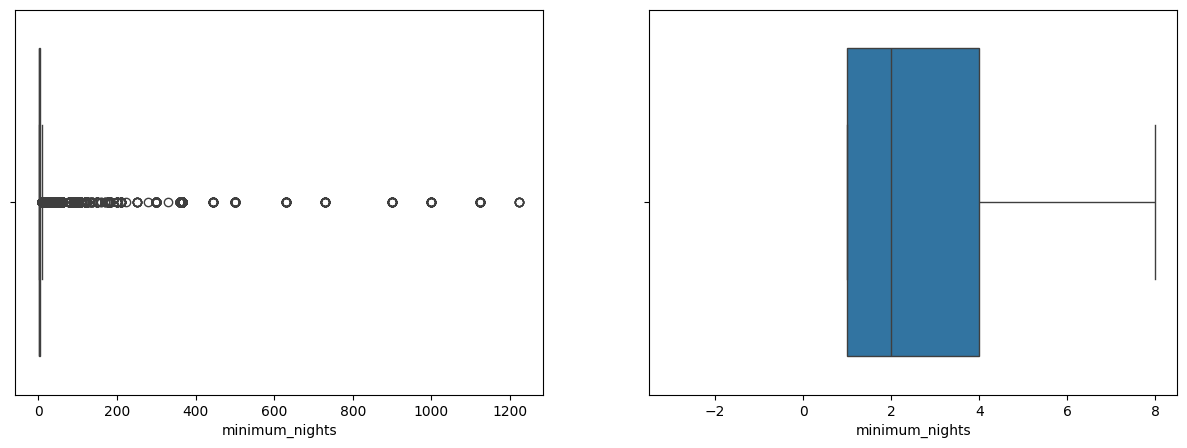

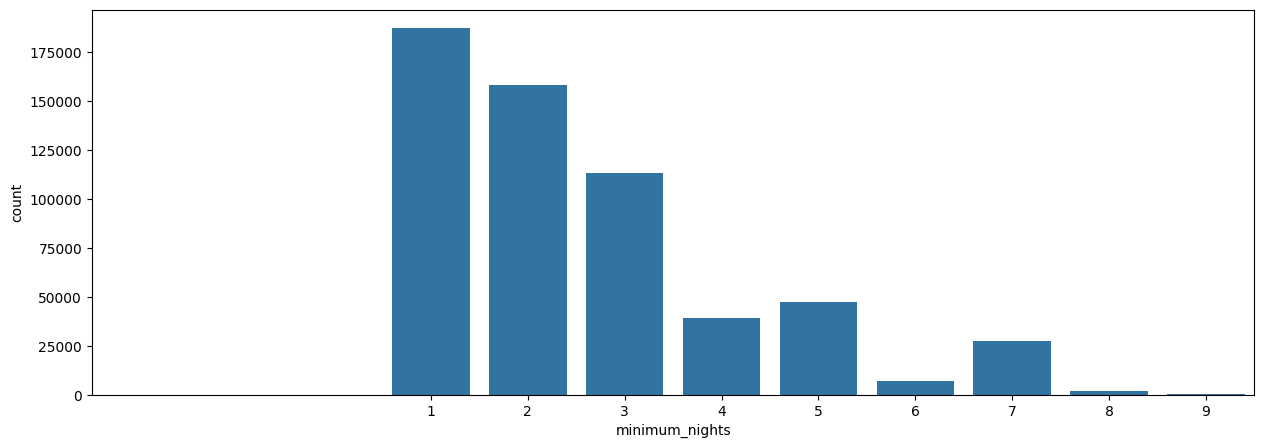

In [153]:
diagrama_caixa(base_airbnb["minimum_nights"])
grafico_barra(base_airbnb["minimum_nights"])

- O objetivo não é visando aluguel por temporada (a pessoa que vai alugar não precisa pegar no mímino 15 noites por exemplo), o objetivo visa uma pessoa que simplesmente quer pegar seu imóvel e colocar para alugar no airbnb

In [154]:
base_airbnb, linhas_removidas = excluir_outliers(base_airbnb, "minimum_nights")
print(f"Linhas removidas {linhas_removidas}")

Linhas removidas 40383


### maximum_nights

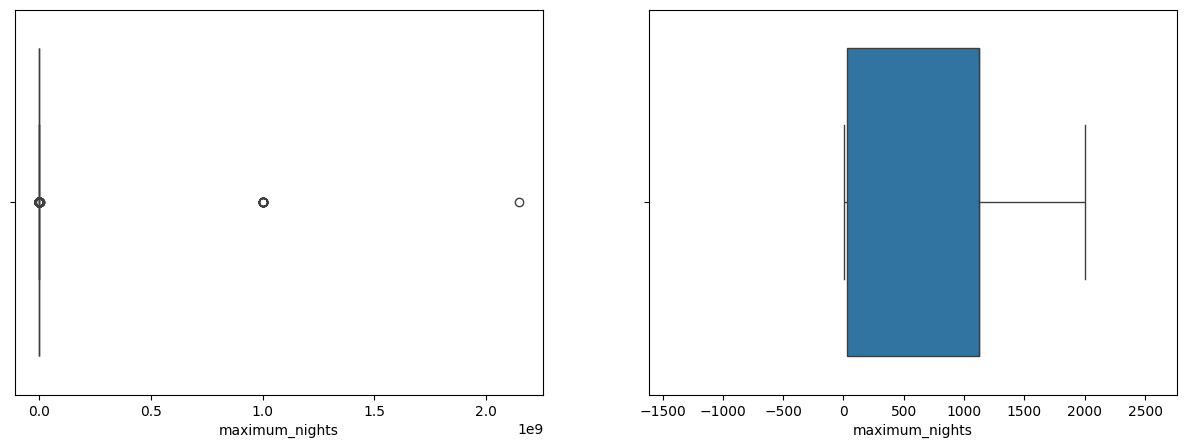

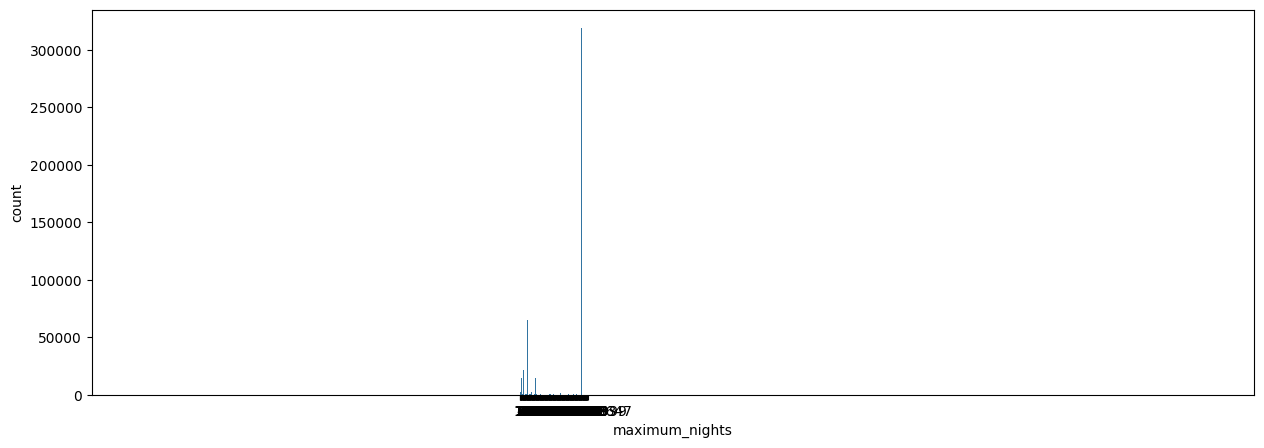

In [155]:
diagrama_caixa(base_airbnb["maximum_nights"])
grafico_barra(base_airbnb["maximum_nights"])

- Não é uma feature útil para a análise, possui muitos valores 0 ou muito absurdos como 1000 noites

In [156]:
base_airbnb = base_airbnb.drop(columns="maximum_nights")
base_airbnb.shape

(581983, 21)

### number_of_reviews         

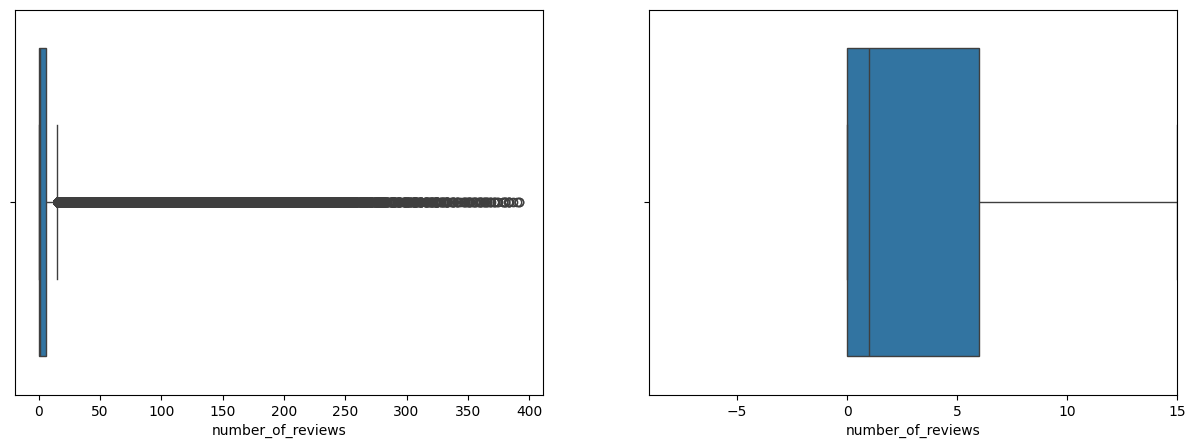

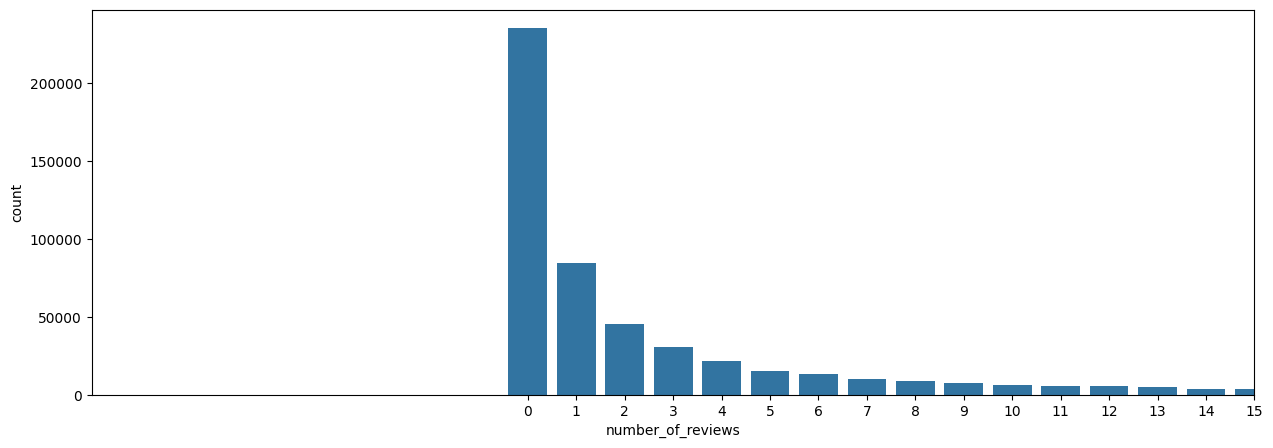

In [157]:
diagrama_caixa(base_airbnb["number_of_reviews"])
grafico_barra(base_airbnb["number_of_reviews"])

 - O objetivo do modelo visa construir um modelo para informar para uma pessoa, que não tem um imóvel no airbnb ou tem mas 
fez poucos alugueis,o quanto ela tem que cobrar, então não tem muita utilidade o número de reviws
pois ela terá nenhuma ou muito pouca

In [158]:
base_airbnb = base_airbnb.drop(columns="number_of_reviews")
base_airbnb.shape

(581983, 20)

### Tratamento de Colunas de Valores de Texto

- property_type

property_type
Apartment                 458354
House                      51387
Condominium                26456
Serviced apartment         12671
Loft                       12352
Guest suite                 3621
Bed and breakfast           3472
Hostel                      2665
Guesthouse                  2155
Other                       1957
Villa                       1294
Townhouse                    969
Aparthotel                   693
Chalet                       481
Earth house                  468
Tiny house                   457
Boutique hotel               447
Hotel                        376
Casa particular (Cuba)       298
Cottage                      230
Bungalow                     207
Dorm                         185
Cabin                        141
Nature lodge                 124
Castle                        80
Treehouse                     76
Island                        54
Boat                          53
Hut                           40
Campsite                     

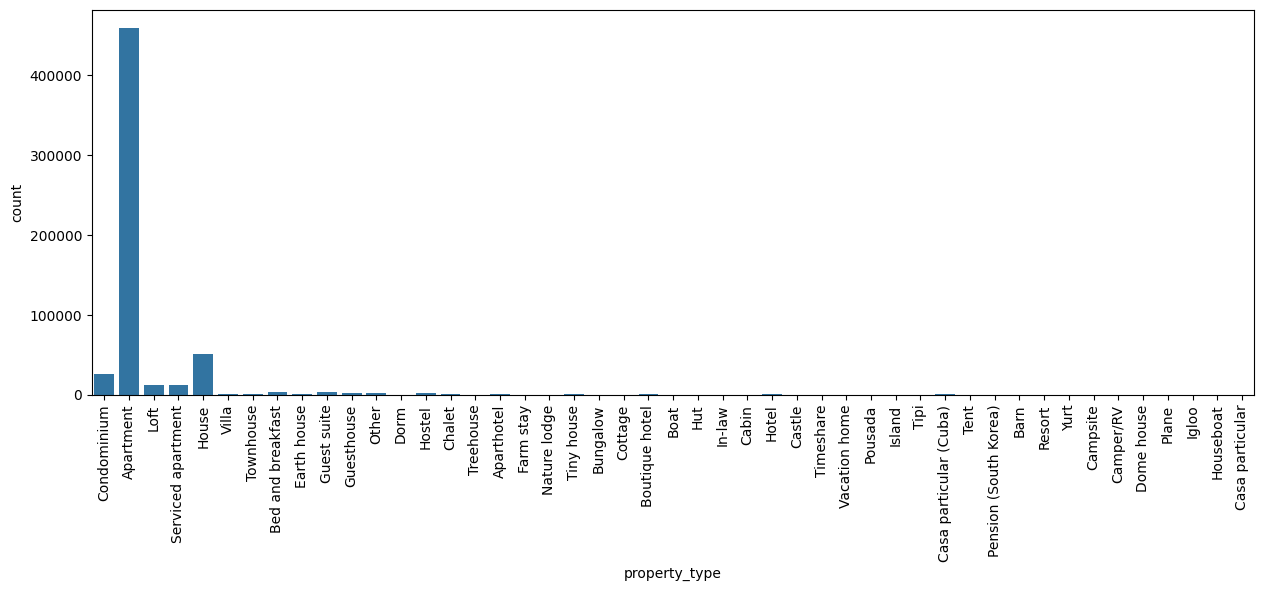

In [159]:
print(base_airbnb["property_type"].value_counts()) # Quantos tipos diferentes de tipos de propriedade tem na base
# Existem alguns dados que são tão escassos que não fazem sentido serem tratados por categorias diferentes

plt.figure(figsize=(15,5))
grafico = sns.countplot(x = "property_type", data=base_airbnb)
grafico.tick_params(axis = "x", rotation = 90)
plt.show()


property_type
Apartment             458354
House                  51387
Condominium            26456
Serviced apartment     12671
Loft                   12352
Outros                  8850
Guest suite             3621
Bed and breakfast       3472
Hostel                  2665
Guesthouse              2155
Name: count, dtype: int64


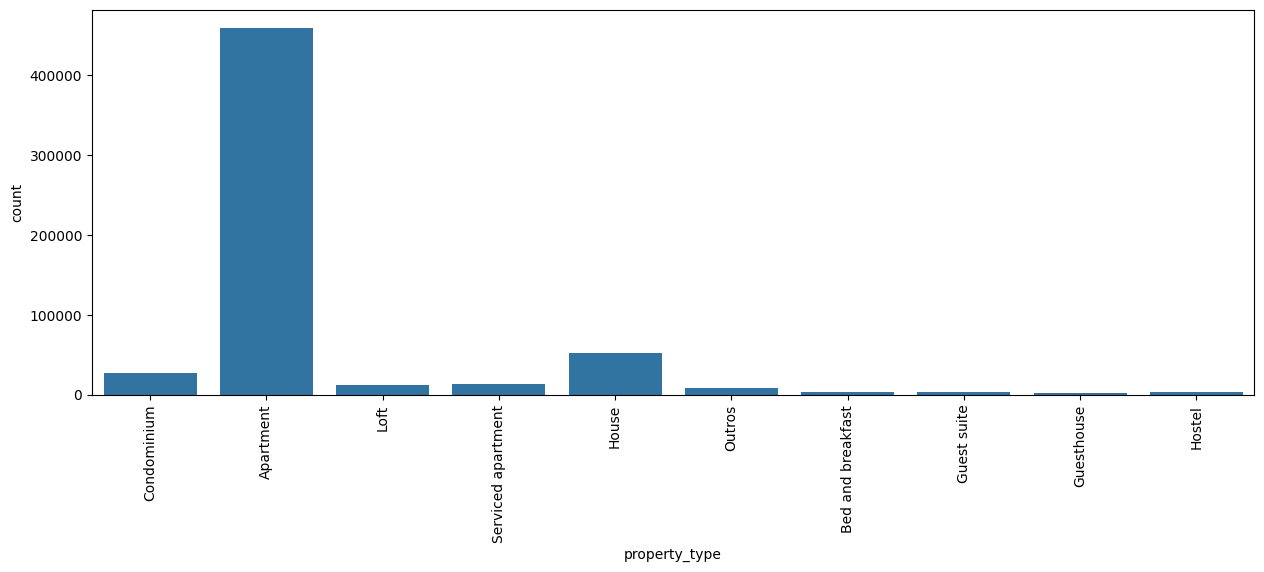

In [160]:
Tabela_tipo_casa = base_airbnb["property_type"].value_counts()

# Criar um filtro, em que serão considerados somente as categorias com menos de 2000 unidades
filtro = Tabela_tipo_casa[Tabela_tipo_casa < 2000].index # retonar os index que se encaixa no filtro

# Substitui todas as categorias da coluna property_type, dentro do filtro, por Outros 
base_airbnb.loc[base_airbnb["property_type"].isin(filtro), "property_type"] = "Outros" 

print(base_airbnb["property_type"].value_counts())

plt.figure(figsize=(15,5))
grafico = sns.countplot(x = "property_type", data=base_airbnb)
grafico.tick_params(axis = "x", rotation = 90)
plt.show()

- room_type

room_type
Entire home/apt    372443
Private room       196859
Shared room         11714
Hotel room            967
Name: count, dtype: int64


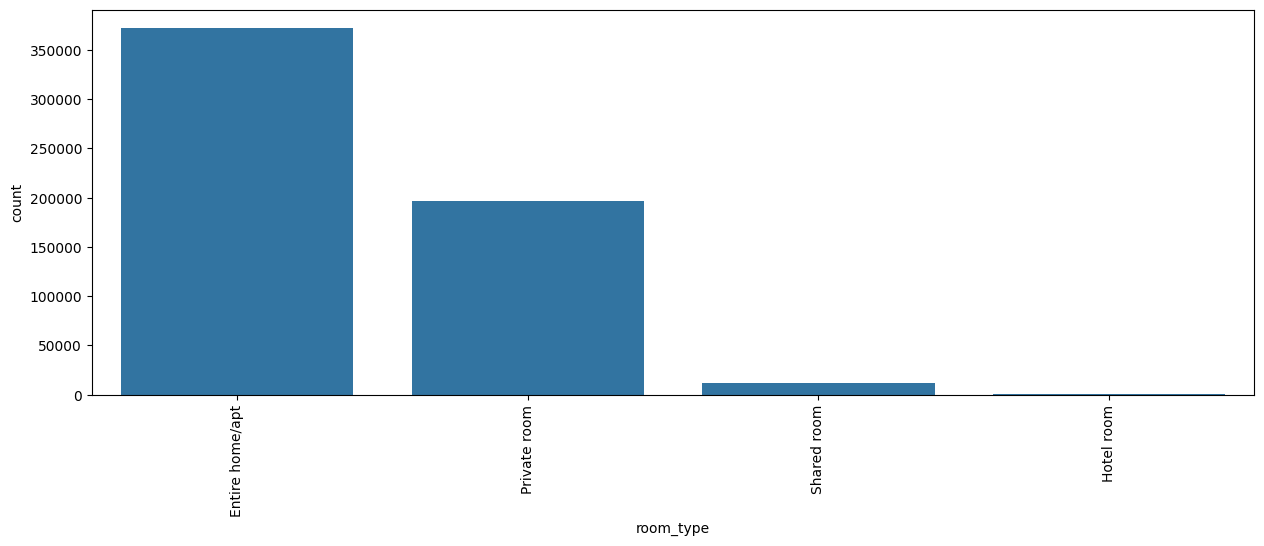

In [161]:
print(base_airbnb["room_type"].value_counts())

plt.figure(figsize=(15,5))
grafico = sns.countplot(x = "room_type", data=base_airbnb)
grafico.tick_params(axis = "x", rotation = 90)
plt.show()

# Nada a alterar, a maioria dos dados estão bem distribuidos

- bed_type 

bed_type
Real Bed         570643
Pull-out Sofa      8055
Futon              1634
Airbed             1155
Couch               496
Name: count, dtype: int64


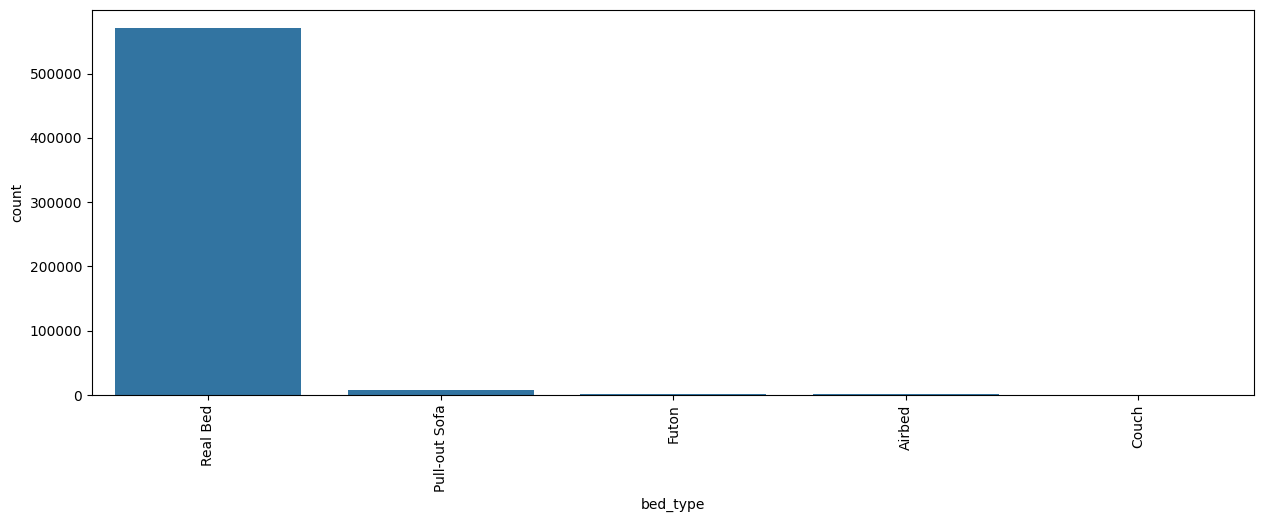

bed_type
Real Bed    570643
Outros       11340
Name: count, dtype: int64


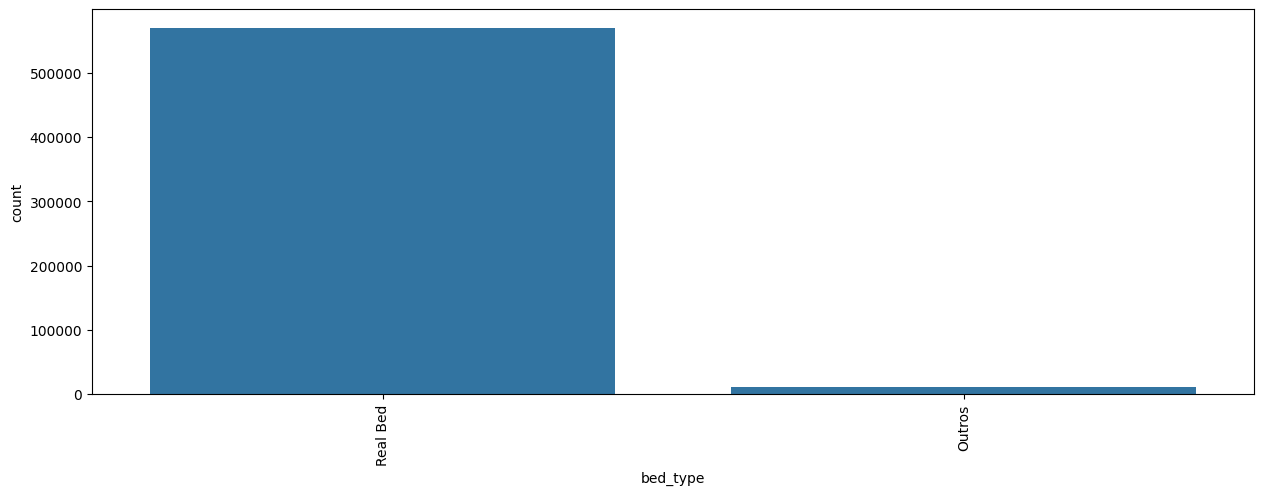

In [162]:
print(base_airbnb["bed_type"].value_counts())

plt.figure(figsize=(15,5))
grafico = sns.countplot(x = "bed_type", data=base_airbnb)
grafico.tick_params(axis = "x", rotation = 90)
plt.show()

# as colunas com valores muito pequenos serão agrupadas
Tabela_tipo_casa = base_airbnb["bed_type"].value_counts()

# Criar um filtro, em que serão considerados somente as categorias com menos de 9000 unidades
filtro = Tabela_tipo_casa[Tabela_tipo_casa < 9000].index # retonar os index que se encaixa no filtro

# Substitui todas as categorias da coluna bed_type, dentro do filtro, por Outros 
base_airbnb.loc[base_airbnb["bed_type"].isin(filtro), "bed_type"] = "Outros" 

print(base_airbnb["bed_type"].value_counts())

plt.figure(figsize=(15,5))
grafico = sns.countplot(x = "bed_type", data=base_airbnb)
grafico.tick_params(axis = "x", rotation = 90)
plt.show()

- cancellation_policy

cancellation_policy
flexible                       258096
strict_14_with_grace_period    200743
moderate                       113281
strict                           9696
super_strict_60                   135
super_strict_30                    32
Name: count, dtype: int64


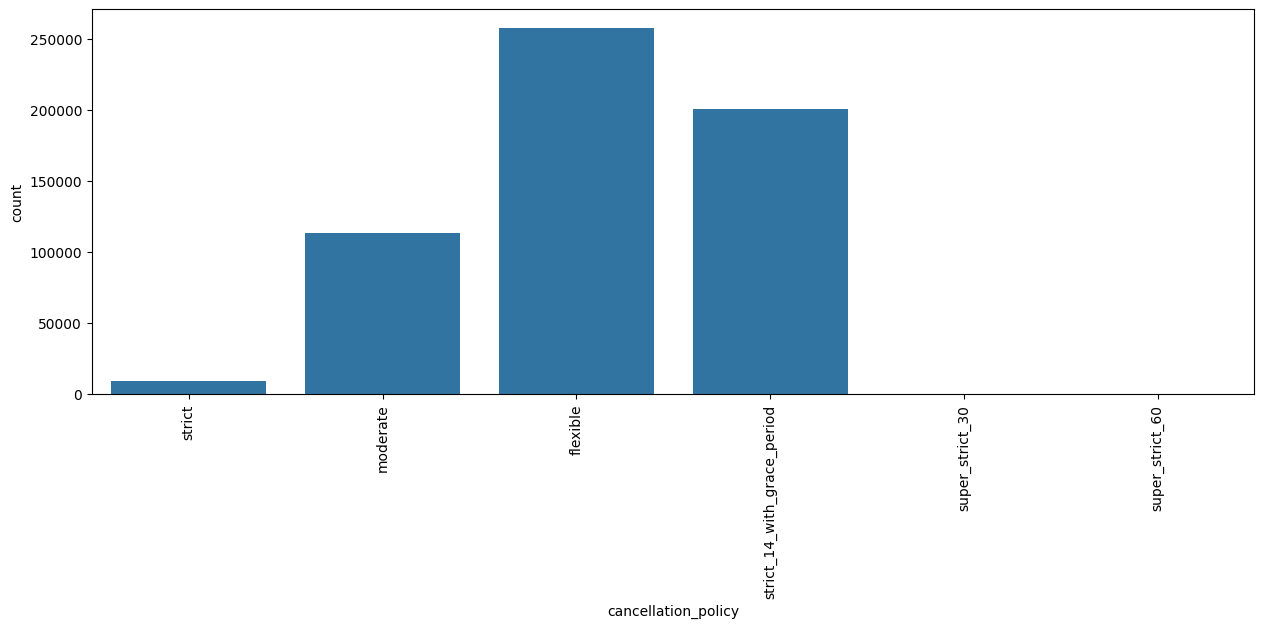

In [163]:
print(base_airbnb["cancellation_policy"].value_counts())

plt.figure(figsize=(15,5))
grafico = sns.countplot(x = "cancellation_policy", data=base_airbnb)
grafico.tick_params(axis = "x", rotation = 90)
plt.show()

# Nesse caso será feito um agrupamento


cancellation_policy
flexible                       258096
strict_14_with_grace_period    200743
moderate                       113281
strict                           9863
Name: count, dtype: int64


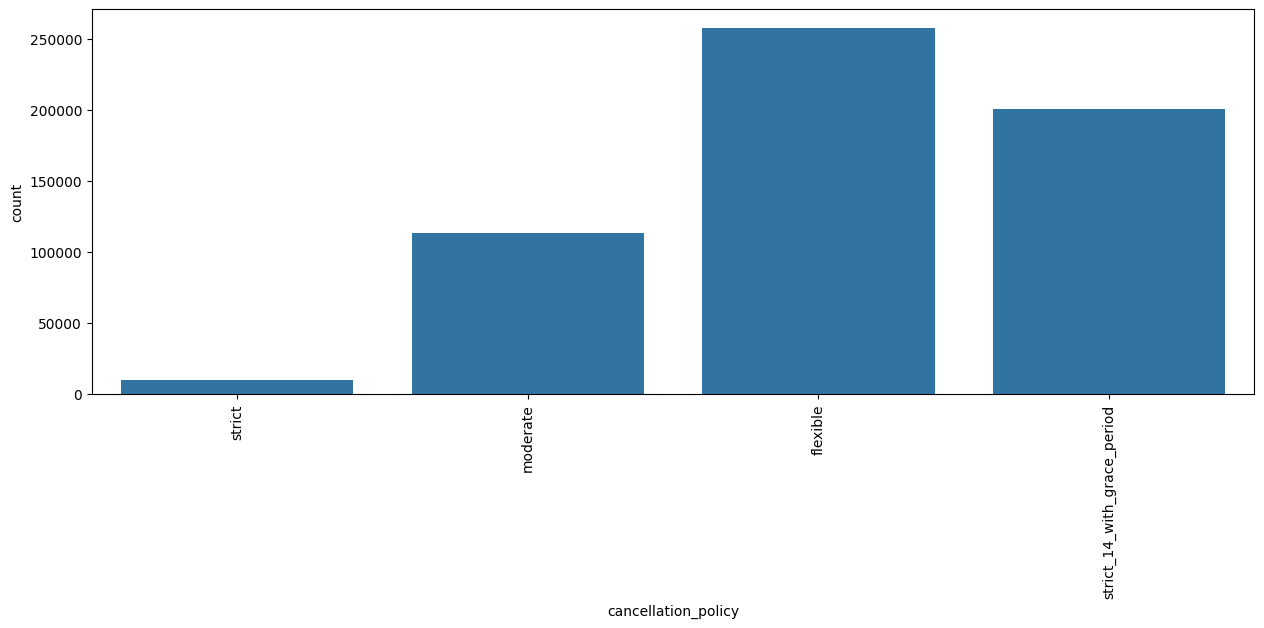

In [164]:
Tipo_cancellation_policy = base_airbnb["cancellation_policy"].value_counts()

# Criar um filtro, em que serão considerados somente as categorias com menos de 10000 unidades
filtro = Tipo_cancellation_policy[Tipo_cancellation_policy < 10000].index # retonar os index que se encaixa no filtro

# Substitui todas as categorias da coluna cancellation_policy, dentro do filtro, por strict 
base_airbnb.loc[base_airbnb["cancellation_policy"].isin(filtro), "cancellation_policy"] = "strict" 

print(base_airbnb["cancellation_policy"].value_counts())

plt.figure(figsize=(15,5))
grafico = sns.countplot(x = "cancellation_policy", data=base_airbnb)
grafico.tick_params(axis = "x", rotation = 90)
plt.show()

- amenities

Pelo fato de existir uma diversidade muito grande de amenities e, ás vezes, as mesmas amenities podem ser escritas de forma diferente, o parâmetro levado em consideração para o modelo será somente a quantidade de amenities

In [165]:
print(base_airbnb["amenities"].iloc[1].split(","))
print(len(base_airbnb["amenities"].iloc[1].split(",")))

base_airbnb["n_amenities"] = base_airbnb["amenities"].str.split(",").apply(len)

['{TV', '"Cable TV"', 'Internet', 'Wifi', '"Air conditioning"', 'Kitchen', 'Doorman', 'Elevator', '"Buzzer/wireless intercom"', '"Family/kid friendly"', 'Hangers', '"Hair dryer"', 'Iron', '"Laptop friendly workspace"}']
14


In [166]:
base_airbnb = base_airbnb.drop(columns="amenities")
print(base_airbnb.shape)

(581983, 20)


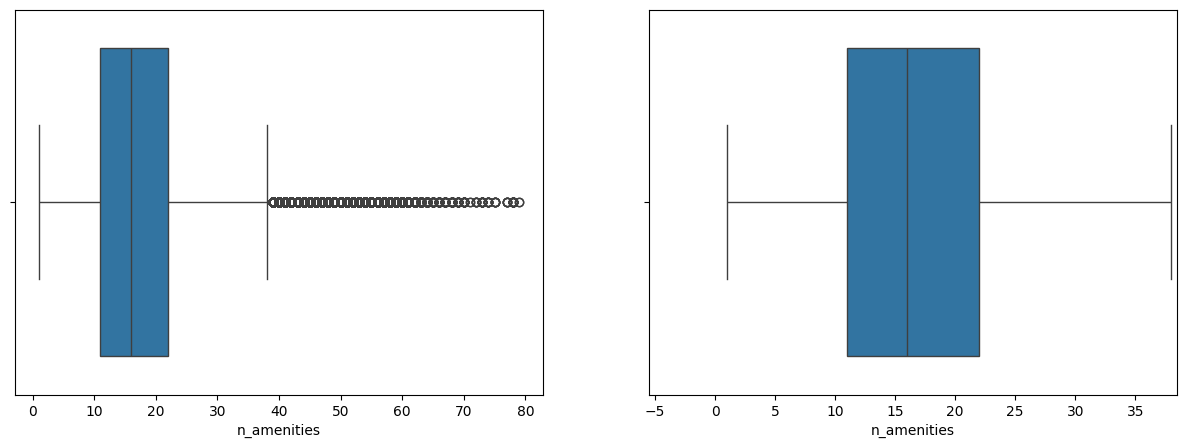

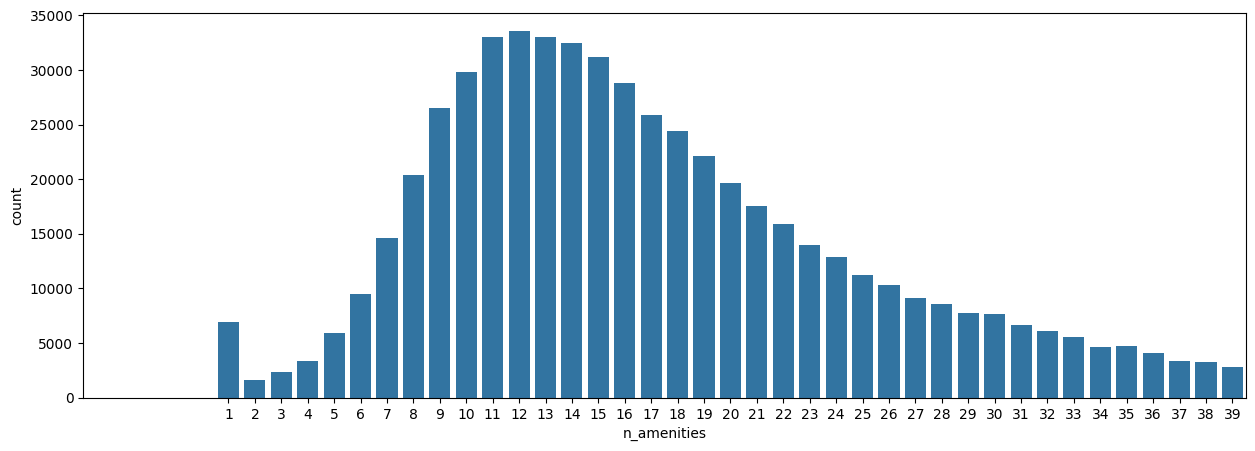

In [167]:
diagrama_caixa(base_airbnb["n_amenities"])
grafico_barra(base_airbnb["n_amenities"])

In [168]:
# Muitos ameties indicam um luxo que está fora do escopo do objetivo do modelo, por isso os outliers serão retirados
base_airbnb, linhas_removidas = excluir_outliers(base_airbnb, "n_amenities")
print(f"Linhas removidas {linhas_removidas}")

Linhas removidas 24343


### Visualização de Mapa das Propriedades

In [169]:
amostra = base_airbnb.sample(50000)
centro_mapa = {"lat": amostra.latitude.mean(), "lon": amostra.longitude.mean()}
mapa = px.density_map(
    amostra,
    lat="latitude",
    lon="longitude",
    z="price",
    radius=2.5,
    center=centro_mapa,
    zoom=10,
    map_style="open-street-map"
)

mapa.show()
# Como o github não renderiza mapas interativos, resolvi salvar o mapa em formato html para melhor vizuaização
mapa.write_html("Mapa_das_Propriedades.html")

### Encoding

- Ajustar as features para facilitar o trabalho do modelo futuro (features de categorias, true e false, etc)
- Features de Valores True ou False, True será substituido por 1 e False por 0
- Feature de categoria (features em que os valores da coluna são textos) vamos utilizar o método de encoding de variáveis dummies

In [170]:
print(base_airbnb.columns)
colunas_tf = ["host_is_superhost","instant_bookable","is_business_travel_ready"]

Index(['host_is_superhost', 'host_listings_count', 'latitude', 'longitude',
       'property_type', 'room_type', 'accommodates', 'bathrooms', 'bedrooms',
       'beds', 'bed_type', 'price', 'extra_people', 'minimum_nights',
       'instant_bookable', 'is_business_travel_ready', 'cancellation_policy',
       'ano', 'mes', 'n_amenities'],
      dtype='str')


In [171]:
colunas_categorias = ["property_type", "room_type", "bed_type", "cancellation_policy"]

In [172]:
# Substituindo os elementos das colunas true ou false
base_airbnb_cod = base_airbnb.copy()

for coluna in colunas_tf:
    base_airbnb_cod[coluna] = (
        base_airbnb_cod[coluna]
        .replace({
            "t": 1,
            "f": 0
        })
        .astype(int)
    )

display(base_airbnb_cod["host_is_superhost"])

1         1
3         0
4         1
5         1
6         1
         ..
902204    0
902205    0
902206    0
902208    0
902209    0
Name: host_is_superhost, Length: 557640, dtype: int64

In [173]:
# Tratando agora as colunas de categorias
base_airbnb_cod = pd.get_dummies(data=base_airbnb_cod, columns=colunas_categorias, dtype=int)
"""
-> pd.get_dummies() do pandas faz One Hot Encoding.
Ele transforma categorias/textos em colunas numéricas binárias (0 e 1).
"""

display(base_airbnb_cod.head())

,host_is_superhost,host_listings_count,latitude,longitude,accommodates,bathrooms,bedrooms,beds,price,extra_people,...,room_type_Entire home/apt,room_type_Hotel room,room_type_Private room,room_type_Shared room,bed_type_Outros,bed_type_Real Bed,cancellation_policy_flexible,cancellation_policy_moderate,cancellation_policy_strict,cancellation_policy_strict_14_with_grace_period
1,1,2.0,-22.965919,-43.178962,5,1.0,2.0,2.0,270.0,51.0,...,1,0,0,0,0,1,0,0,1,0
3,0,3.0,-22.977117,-43.190454,3,1.0,1.0,2.0,161.0,45.0,...,1,0,0,0,0,1,0,0,1,0
4,1,1.0,-22.983024,-43.214270,3,1.0,1.0,2.0,222.0,68.0,...,1,0,0,0,0,1,0,0,1,0
5,1,1.0,-22.988165,-43.193588,3,1.5,1.0,2.0,308.0,86.0,...,1,0,0,0,0,1,0,0,1,0
6,1,1.0,-22.981269,-43.190457,2,1.0,1.0,2.0,219.0,80.0,...,1,0,0,0,0,1,0,0,1,0


### Modelo de Previsão

- Métricas de Avaliação

In [174]:
def avaliar_modelo(nome_modelo, y_teste, previsao):
    r2 = r2_score(y_teste, previsao)
    RSME = np.sqrt(mean_squared_error(y_teste, previsao))
    return f'Modelo {nome_modelo}:\n R^2: {r2:.2%}\nRSME:{RSME:.2f}'

- Escolha dos Modelos a Serem Testados
1. RandomForest
2. LinearRegression
3. Extra tree

In [175]:
modelo_rf = RandomForestRegressor()
modelo_lr = LinearRegression()
modelo_et = ExtraTreesRegressor()
modelos = {"RandomForest": modelo_rf,
           "LinearRegression": modelo_lr,
           "ExtraTrees": modelo_et,
}

y = base_airbnb_cod["price"]
x = base_airbnb_cod.drop(columns="price")

- Separa os dados em treino e teste + Treino do Modelo

In [176]:
x_train, x_test, y_train, y_test = train_test_split(x, y, random_state=10)

for nome_modelo, modelo in modelos.items():
    # treinar
    modelo.fit(x_train, y_train)
    # testar
    previsao = modelo.predict(x_test)
    print(avaliar_modelo(nome_modelo, y_test, previsao))

Modelo RandomForest:
 R^2: 97.25%
RSME:44.01
Modelo LinearRegression:
 R^2: 32.70%
RSME:217.54
Modelo ExtraTrees:
 R^2: 97.49%
RSME:42.02


### Análise do Melhor Modelo

In [177]:
for nome_modelo, modelo in modelos.items():
    # testar
    previsao = modelo.predict(x_test)
    print(avaliar_modelo(nome_modelo, y_test, previsao))

Modelo RandomForest:
 R^2: 97.25%
RSME:44.01
Modelo LinearRegression:
 R^2: 32.70%
RSME:217.54
Modelo ExtraTrees:
 R^2: 97.49%
RSME:42.02


- Modelo escolhido como Melhor Modelo: ExtraTressRegressor
    - Esse foi o modelo com maior valor de R² e a mesmo tempo o menor valor de RSME. Como não teve uma grande diferença de velocidade de treino e de previsão desse modelo com o modelo de RandomForest (que teve resultados próximos de R² e RSME) - será escolhido o modelo ExtraTrees.
    - O modelo de regressão linear não teve um resultado satisfatório, com valores de R² e RSME muito pior do que os outros dois modelos.
- Resultado do modelo vencedor:
    - Modelo ExtraTrees:
    - R^2: 97.52%
    - RSME:41.75

### Ajustes e Melhorias no Melhor Modelo

In [178]:
print(modelo_et.feature_importances_) 
# modelo_et.feature_importances_ -> A importância de cada uma das features para o resultado final, os dados aparecem
# na ordem que estão no X_train
print(x_train.columns)


[0.01327043 0.03986782 0.10386151 0.10143895 0.07181351 0.06682077
 0.11986321 0.05253329 0.08584251 0.06510443 0.02180204 0.
 0.01131434 0.00470173 0.08933177 0.01263905 0.00127842 0.00521893
 0.00067491 0.00093404 0.00065487 0.00707845 0.00213641 0.00240129
 0.00228664 0.06521002 0.00031219 0.00403599 0.00187777 0.00262843
 0.00269033 0.01969166 0.01211435 0.00083973 0.00773021]
Index(['host_is_superhost', 'host_listings_count', 'latitude', 'longitude',
       'accommodates', 'bathrooms', 'bedrooms', 'beds', 'extra_people',
       'minimum_nights', 'instant_bookable', 'is_business_travel_ready', 'ano',
       'mes', 'n_amenities', 'property_type_Apartment',
       'property_type_Bed and breakfast', 'property_type_Condominium',
       'property_type_Guest suite', 'property_type_Guesthouse',
       'property_type_Hostel', 'property_type_House', 'property_type_Loft',
       'property_type_Outros', 'property_type_Serviced apartment',
       'room_type_Entire home/apt', 'room_type_Hotel r

,0
bedrooms,0.119863
latitude,0.103862
longitude,0.101439
n_amenities,0.089332
extra_people,0.085843
accommodates,0.071814
bathrooms,0.066821
room_type_Entire home/apt,0.065210
minimum_nights,0.065104
beds,0.052533


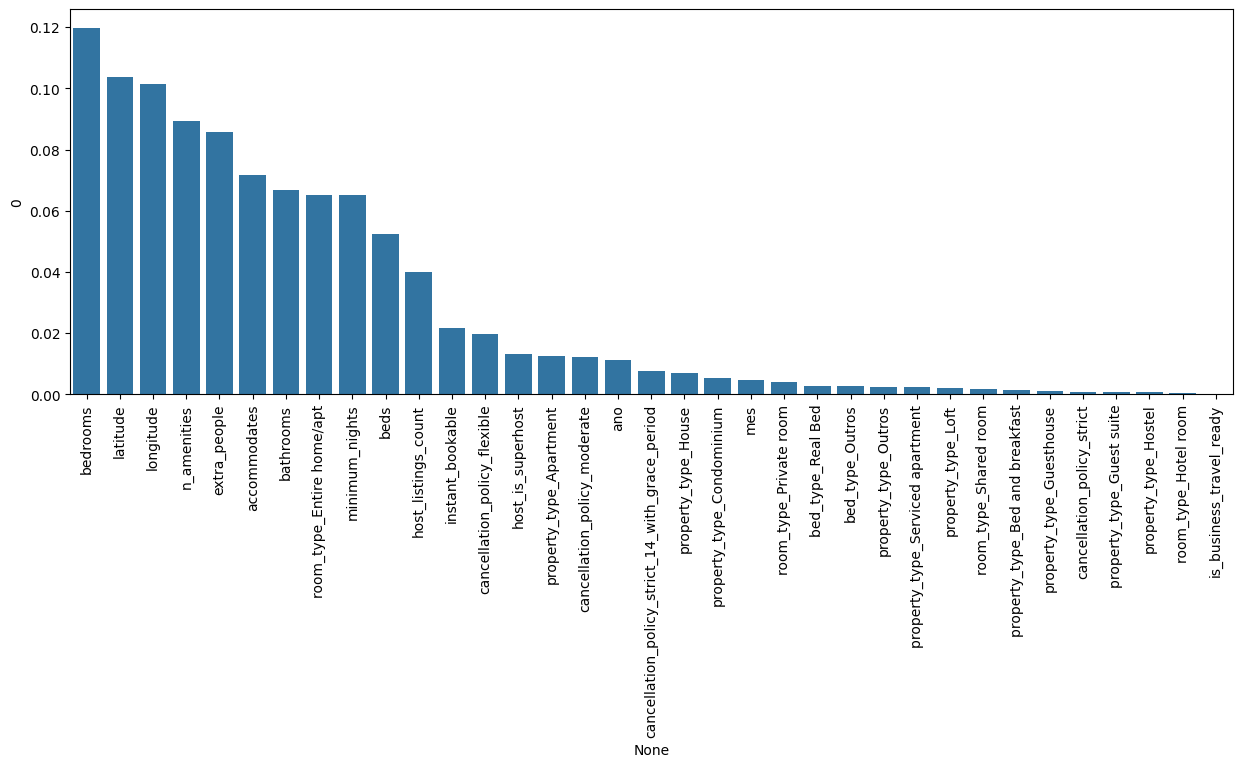

In [179]:
importancia_features = pd.DataFrame(modelo_et.feature_importances_, x_train.columns)
#(dados, índices)
importancia_features = importancia_features.sort_values(by=0, ascending=False)
display(importancia_features)

plt.figure(figsize=(15,5))
ax = sns.barplot(x = importancia_features.index, y = importancia_features[0])
ax.tick_params(axis="x", rotation = 90)
plt.show()

### Ajustes finais no modelo

- is_business_travel_ready não parece ter muito impacto no nosso modelo. Por isso, para chegar em um modelo mais simples, será retirada e o modelo será testado sem ela.

In [180]:
base_airbnb_cod = base_airbnb_cod.drop(columns = "is_business_travel_ready")
y = base_airbnb_cod["price"]
x = base_airbnb_cod.drop(columns="price")

x_train, x_test, y_train, y_test = train_test_split(x, y, random_state=10)

# treinar
modelo.fit(x_train, y_train)
# testar
previsao = modelo.predict(x_test)
print(avaliar_modelo("ExtraTrees", y_test, previsao))

Modelo ExtraTrees:
 R^2: 97.49%
RSME:42.00


### Deploy do Projeto
- Passo 1 -> Criar arquivo do Modelo (joblib)
- Passo 2 -> Escolher a forma de deploy:
    - Arquivo Executável + Tkinter
    - Deploy em um microsite (Flask)
    - Deploy apenas para uso direto (Streamlit)
- Passo 3 -> Outro arquivo Python (pode ser Jupyter ou Pycharm)
- Passo 4 -> Importar streamlit e criar código
- Passo 5 -> Atribuir ao botão o carregamento do modelo
- Passo 6 -> Deploy feito

In [181]:
x["price"] = y
x.to_csv("dados.csv", sep=";", index=False)

In [182]:
import joblib
joblib.dump(modelo_et, "modelo.joblib")

['modelo.joblib']